In [1]:
# ================================
# 1. DATA UNDERSTANDING
# ================================
import pandas as pd

# Load data
train = pd.read_csv("train.csv")

print("5 Data Teratas:")
print(train.head())

print("\nInfo Dataset:")
print(train.info())

print("\nStatistik Deskriptif:")
print(train.describe())

print("\nNama Kolom:")
print(train.columns)

5 Data Teratas:
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----

In [2]:
# ================================
# 2. DATA PREPROCESSING
# ================================
import numpy as np

# Copy data 
df = train.copy()

#  HAPUS DATA LEAKAGE
df = df.drop(columns=['casual', 'registered'])

# ----- HANDLE MISSING VALUE -----
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing value setelah cleaning:")
print(df.isnull().sum())


# ================================
# TAMBAHAN: HANDLE OUTLIER (IQR)
# ================================
for col in df.select_dtypes(include=np.number).columns:
    if col != 'count':  
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # CAPPING
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Total data setelah preprocessing:", len(df))

# ================================
# FEATURE ENGINEERING
# ================================

# Ubah datetime
df['datetime'] = pd.to_datetime(df['datetime'])

# Ekstrak fitur waktu
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['dayofweek'] = df['datetime'].dt.dayofweek

# 🔥 fitur tambahan penting
df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
df['temp_diff'] = df['temp'] - df['atemp']
df['time_category'] = df['hour'].apply(
    lambda x: 0 if 0 <= x <= 5 else
              1 if 6 <= x <= 9 else
              2 if 10 <= x <= 15 else
              3 if 16 <= x <= 19 else
              4
)


# Drop datetime
df = df.drop(columns=['datetime'])

print("\nFitur setelah FE:")
print(df.columns)

# ================================
# SIMPAN HASIL PREPROCESSING KE CSV
# ================================
df.to_csv("data_bersih_fe.csv", index=False)

print("\nFile berhasil disimpan sebagai data_bersih_fe.csv")



Missing value setelah cleaning:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
dtype: int64
Total data setelah preprocessing: 10886


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1564\194406604.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_1564\194406604.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example


Fitur setelah FE:
Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'count', 'hour', 'day', 'month', 'dayofweek',
       'is_weekend', 'temp_diff', 'time_category'],
      dtype='object')

File berhasil disimpan sebagai data_bersih_fe.csv


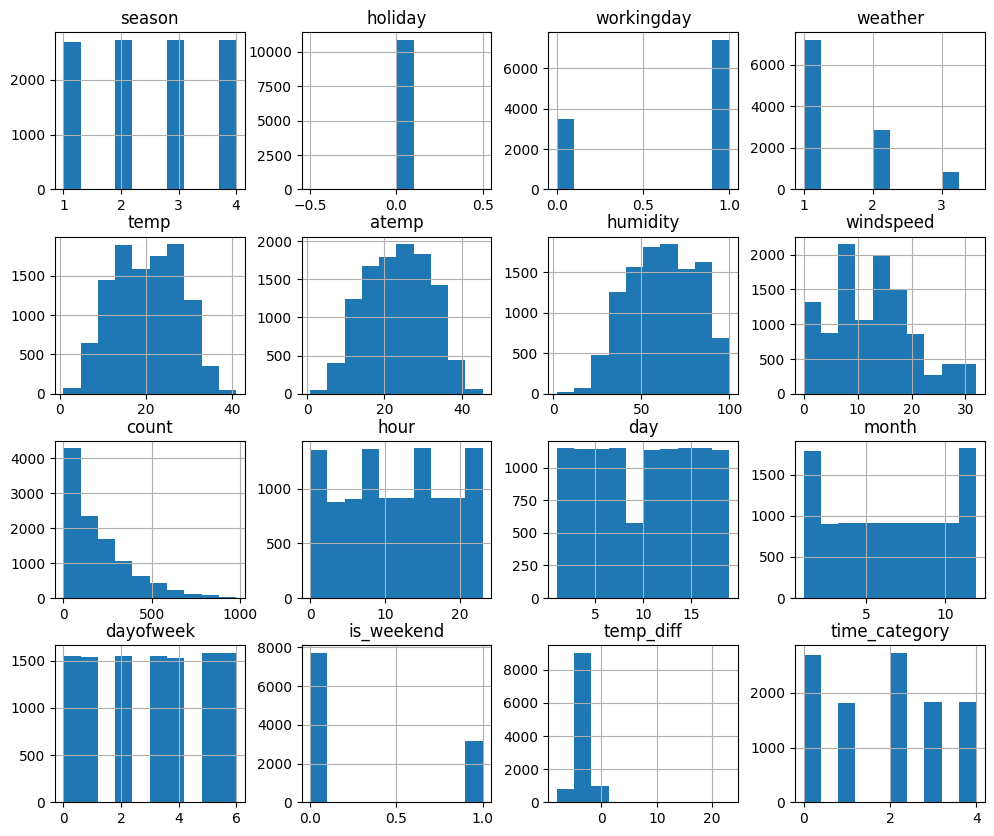

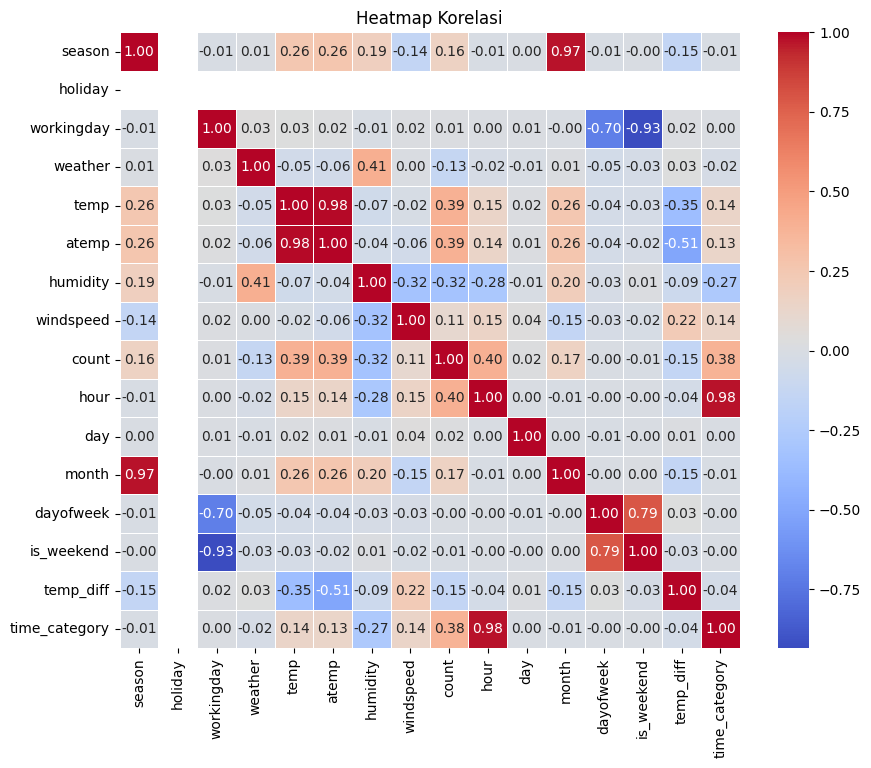

In [3]:
# ================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi
df.hist(figsize=(12,10))
plt.show()

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=True,        
    fmt=".2f",        
    linewidths=0.5     
)

plt.title("Heatmap Korelasi")
plt.show()

In [4]:
# ================================
# 5. DATA SPLITTING
# ================================
from sklearn.model_selection import train_test_split

target = 'count'

X = df.drop(columns=[target])
y = df[target]

splits = [
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1)
]

In [5]:
# ================================
# 6. MODEL BUILDING 
# ================================
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

baseline_results = []

for train_size, test_size in splits:
    print(f"\n===== BASELINE Split {train_size}:{test_size} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ========================
    # RANDOM FOREST 
    # ========================
    rf = RandomForestRegressor()
    rf.fit(X_train, y_train)

    rf_pred = rf.predict(X_test)
    rf_r2 = r2_score(y_test, rf_pred)

    print("Random Forest:", rf_r2)

    # ========================
    # XGBOOST 
    # ========================
    xgb = XGBRegressor()
    xgb.fit(X_train, y_train)

    xgb_pred = xgb.predict(X_test)
    xgb_r2 = r2_score(y_test, xgb_pred)

    print("XGBoost:", xgb_r2)

    # ========================
    # LIGHTGBM 
    # ========================
    lgbm = LGBMRegressor()
    lgbm.fit(X_train, y_train)

    lgbm_pred = lgbm.predict(X_test)
    lgbm_r2 = r2_score(y_test, lgbm_pred)

    print("LightGBM:", lgbm_r2)

    # Simpan hasil
    baseline_results.append({
        "Split": f"{int(train_size*100)}:{int(test_size*100)}",
        "RandomForest": rf_r2,
        "XGBoost": xgb_r2,
        "LightGBM": lgbm_r2
    })

# Ubah ke DataFrame
df_baseline = pd.DataFrame(baseline_results)

# Optional: biar lebih rapi di Jupyter Notebook
display(df_baseline)


===== BASELINE Split 0.7:0.3 =====
Random Forest: 0.8649136688767556
XGBoost: 0.8921141028404236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 496
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 14
[LightGBM] [Info] Start training from score 191.370341
LightGBM: 0.881805589487451

===== BASELINE Split 0.8:0.2 =====
Random Forest: 0.8702395480624174
XGBoost: 0.9000357389450073
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001085 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 502
[LightGBM] [Info] Number of data points in the train set: 8708, number of used features: 14
[LightGBM] [Info] Start training from score 191.584750
LightGBM: 0.889233190007582


,Split,RandomForest,XGBoost,LightGBM
0,70:30,0.864914,0.892114,0.881806
1,80:20,0.870240,0.900036,0.889233
2,90:10,0.879074,0.903161,0.892195


In [ ]:
# ================================
# 7. TRAINING + HYPERPARAMETER TUNING
# ================================
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

tuning_results = []

for train_size, test_size in splits:
    print(f"\n===== TUNING Split {train_size}:{test_size} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ========================
    # RANDOM FOREST (TUNING)
    # ========================
    rf = RandomForestRegressor()

    rf_params = {
        'n_estimators': [200, 300],
        'max_depth': [10, 15]
    }

    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2')
    rf_grid.fit(X_train, y_train)

    rf_pred = rf_grid.predict(X_test)
    rf_r2 = r2_score(y_test, rf_pred)

    print("Random Forest:", rf_r2)

    # ========================
    # XGBOOST (TUNING)
    # ========================
    xgb = XGBRegressor()

    xgb_params = {
        'n_estimators': [300, 500],
        'max_depth': [6, 8],
        'learning_rate': [0.05],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    }

    xgb_random = RandomizedSearchCV(xgb, xgb_params, n_iter=4, cv=3, scoring='r2')
    xgb_random.fit(X_train, y_train)

    xgb_pred = xgb_random.predict(X_test)
    xgb_r2 = r2_score(y_test, xgb_pred)

    print("XGBoost:", xgb_r2)

    # ========================
    # LIGHTGBM (TUNING)
    # ========================
    lgbm = LGBMRegressor()

    lgbm_params = {
        'n_estimators': [300, 500],
        'num_leaves': [31, 50],
        'learning_rate': [0.05],
        'subsample': [0.8]
    }

    lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=3, scoring='r2')
    lgbm_grid.fit(X_train, y_train)

    lgbm_pred = lgbm_grid.predict(X_test)
    lgbm_r2 = r2_score(y_test, lgbm_pred)

    print("LightGBM:", lgbm_r2)

    # Simpan hasil
    tuning_results.append({
        "Split": f"{int(train_size*100)}:{int(test_size*100)}",
        "RandomForest": rf_r2,
        "XGBoost": xgb_r2,
        "LightGBM": lgbm_r2
    })

    # Ubah ke DataFrame
df_tuning = pd.DataFrame(tuning_results)

# Tampilkan tabel
print("\n=== Tabel Perbandingan Tuning ===")
print(df_tuning)

# Optional (lebih rapi di Jupyter)
display(df_tuning)


===== TUNING Split 0.7:0.3 =====


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

evaluation_results = []

for train_size, test_size in splits:
    print(f"\n===== EVALUASI Split {train_size}:{test_size} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ========================
    # RANDOM FOREST 
    # ========================
    rf = RandomForestRegressor()
    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='r2')
    rf_grid.fit(X_train, y_train)

    rf_best = rf_grid.best_estimator_
    rf_pred = rf_best.predict(X_test)

    # ========================
    # XGBOOST 
    # ========================
    xgb = XGBRegressor()
    xgb_random = RandomizedSearchCV(xgb, xgb_params, n_iter=4, cv=3, scoring='r2')
    xgb_random.fit(X_train, y_train)

    xgb_best = xgb_random.best_estimator_
    xgb_pred = xgb_best.predict(X_test)

    # ========================
    # LIGHTGBM 
    # ========================
    lgbm = LGBMRegressor()
    lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=3, scoring='r2')
    lgbm_grid.fit(X_train, y_train)

    lgbm_best = lgbm_grid.best_estimator_
    lgbm_pred = lgbm_best.predict(X_test)

    # ========================
    # HITUNG METRIK 
    # ========================
    for name, pred in zip(
        ["RandomForest", "XGBoost", "LightGBM"],
        [rf_pred, xgb_pred, lgbm_pred]
    ):
        mae = mean_absolute_error(y_test, pred)
        mse = mean_squared_error(y_test, pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, pred)

        print(f"\n{name}")
        print("MAE :", mae)
        print("MSE :", mse)
        print("RMSE:", rmse)
        print("R2  :", r2)

        evaluation_results.append({
            "Split": f"{int(train_size*100)}:{int(test_size*100)}",
            "Model": name,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R2": r2
        })

# ========================
# TABEL HASIL
# ========================
df_eval = pd.DataFrame(evaluation_results)

print("\n=== Tabel Evaluasi Model ===")
display(df_eval)


===== EVALUASI Split 0.7:0.3 =====
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000660 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 476
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 14
[LightGBM] [Info] Start training from score 194.899016
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 475
[LightGBM] [Info] Number of data points in the train set: 5080, number of used features: 14
[LightGBM] [Info] Start training from score 188.528937
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000383 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 476
[LightGBM] [Info] Num

,Split,Model,MAE,MSE,RMSE,R2
0,70:30,RandomForest,44.894623,4487.706154,66.990344,0.862088
1,70:30,XGBoost,34.584908,2883.613525,53.699288,0.911383
2,70:30,LightGBM,36.237133,3046.045264,55.190989,0.906392
3,80:20,RandomForest,44.171237,4346.722778,65.929681,0.868309
4,80:20,XGBoost,33.356258,2676.020264,51.730264,0.918926
5,80:20,LightGBM,34.677404,2772.088516,52.650627,0.916015
6,90:10,RandomForest,42.947431,4159.763329,64.496227,0.874325
7,90:10,XGBoost,31.678181,2457.147949,49.569627,0.925765
8,90:10,LightGBM,32.871128,2610.708825,51.095096,0.921125


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

overfit_results = []

for train_size, test_size in splits:
    print(f"\n===== OVERFITTING CHECK Split {train_size}:{test_size} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ========================
    # RANDOM FOREST
    # ========================
    rf = RandomForestRegressor()
    rf.fit(X_train, y_train)

    # Training score
    rf_train = rf.score(X_train, y_train)

    # Validation (Cross Validation)
    rf_val = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2').mean()

    # Testing score
    rf_test = r2_score(y_test, rf.predict(X_test))

    print(f"RF -> Train: {rf_train}, Val: {rf_val}, Test: {rf_test}")

    # ========================
    # XGBOOST
    # ========================
    xgb = XGBRegressor()
    xgb.fit(X_train, y_train)

    xgb_train = xgb.score(X_train, y_train)
    xgb_val = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2').mean()
    xgb_test = r2_score(y_test, xgb.predict(X_test))

    print(f"XGB -> Train: {xgb_train}, Val: {xgb_val}, Test: {xgb_test}")

    # ========================
    # LIGHTGBM
    # ========================
    lgbm = LGBMRegressor()
    lgbm.fit(X_train, y_train)

    lgbm_train = lgbm.score(X_train, y_train)
    lgbm_val = cross_val_score(lgbm, X_train, y_train, cv=5, scoring='r2').mean()
    lgbm_test = r2_score(y_test, lgbm.predict(X_test))

    print(f"LGBM -> Train: {lgbm_train}, Val: {lgbm_val}, Test: {lgbm_test}")

    # Simpan hasil
    overfit_results.append({
        "Split": f"{int(train_size*100)}:{int(test_size*100)}",

        "RF_Train": rf_train,
        "RF_Val": rf_val,
        "RF_Test": rf_test,

        "XGB_Train": xgb_train,
        "XGB_Val": xgb_val,
        "XGB_Test": xgb_test,

        "LGBM_Train": lgbm_train,
        "LGBM_Val": lgbm_val,
        "LGBM_Test": lgbm_test,
    })

# ========================
# TABEL HASIL
# ========================
df_overfit = pd.DataFrame(overfit_results)

print("\n=== Tabel Overfitting Check ===")
display(df_overfit)


===== OVERFITTING CHECK Split 0.7:0.3 =====
RF -> Train: 0.9818485666348391, Val: 0.862331531763864, Test: 0.8631081436553801
XGB -> Train: 0.9632063508033752, Val: 0.8873071074485779, Test: 0.8921141028404236
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000176 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 496
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 14
[LightGBM] [Info] Start training from score 191.370341
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 483
[LightGBM] [Info] Number of data points in the train set: 6096, number of used features: 14
[LightGBM] [Info] Start training from score 193.382874
[LightGBM] [Info] Auto-choosing col-wise 

,Split,RF_Train,RF_Val,RF_Test,XGB_Train,XGB_Val,XGB_Test,LGBM_Train,LGBM_Val,LGBM_Test
0,70:30,0.981849,0.862332,0.863108,0.963206,0.887307,0.892114,0.922134,0.878723,0.881806
1,80:20,0.982321,0.865780,0.868284,0.960757,0.892056,0.900036,0.920735,0.878924,0.889233
2,90:10,0.982503,0.867322,0.878843,0.959315,0.894600,0.903161,0.918630,0.881167,0.892195


In [ ]:
# ========================
# FINAL MODEL (90:10)
# ========================
from sklearn.model_selection import train_test_split
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

xgb = XGBRegressor()

xgb_params = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8],
    'learning_rate': [0.05],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

xgb_random = RandomizedSearchCV(
    xgb, xgb_params, n_iter=4, cv=3, scoring='r2'
)

xgb_random.fit(X_train, y_train)

best_model = xgb_random.best_estimator_

# SAVE
joblib.dump(best_model, "model_xgb.pkl")
joblib.dump(X.columns.tolist(), "fitur.pkl")

print("🔥 Model siap deploy!")

🔥 Model siap deploy!
